When you extract frequent itemsets (words or sets of words that appear together often across your sentences), you reveal underlying structure:

Sentences that share many frequent itemsets are likely to be similar—for example, about the same topic or intent.

This means your sentences can be grouped (clustered) based on how much they “share” these itemsets.

# Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from itertools import combinations, islice
import ast
import math

# Data Input (data inputed already cleaned from TF-IDF)

Input the data, split each sentence into words, and remove punctuation except for apostrophes.

In [7]:
data = pd.read_csv('../data/horoscope_cleaned_final.csv')

data.columns
#data = data.head(10000)

Index(['ID', 'sign', 'category', 'date', 'horoscope', 'horoscope_cleaned'], dtype='object')

In [8]:
#data.rename(columns={'horoscope': 'token'}, inplace=True)
data.rename(columns={'horoscope_cleaned': 'token'}, inplace=True)

In [9]:
import re

def clean_keep_apostrophe(text):
    # Only keep letters, digits, apostrophes, and whitespace
    return re.sub(r"[^\w\d'\s]", "", text)

# Apply to your DataFrame
data['token'] = data['token'].apply(clean_keep_apostrophe)
data['token'] = data['token'].str.split()
data["token"] = data["token"].apply(lambda x: [w.lower() for w in x])

In [10]:
data

,ID,sign,category,date,horoscope,token
0,1,aries,general,20200617,"There's a great day ahead of you, Aries. You'l...","[there's, great, ahead, you'll, blessed, abili..."
1,2,aries,general,20200618,People will understand and appreciate your des...,"[understand, appreciate, desire, stand, crowd,..."
2,3,aries,general,20200619,You are very interested in technological break...,"[interested, technological, breakthroughs, inn..."
3,4,aries,general,20200620,Stress from overwork could have you feeling we...,"[stress, overwork, feeling, weaker, usual, tem..."
4,5,aries,general,20200621,This is a good day to stand up for yourself an...,"[stand, known, aren't, pushover, use, powerful..."
...,...,...,...,...,...,...
17562,21589,pisces,wellness,20210612,The current planetary influence encourages you...,"[current, influence, encourages, question, per..."
17563,21590,pisces,wellness,20210613,Take a look at what matters most to you in the...,"[look, matters, most, world, somewhere, list, ..."
17564,21591,pisces,wellness,20210614,The balancing acts our bodies perform daily ta...,"[balancing, acts, our, bodies, perform, daily,..."
17565,21592,pisces,wellness,20210615,Today's planetary configuration could make you...,"[configuration, sense, loneliness, realize, im..."


In [11]:
data["original_token_size"] = data["token"].apply(len)
data["original_token_size"].describe()

count    17567.000000
mean        27.597256
std          7.764977
min         10.000000
25%         22.000000
50%         27.000000
75%         32.000000
max         85.000000
Name: original_token_size, dtype: float64

In [12]:
# -- SENTENCES : list of lists of unique items --
# I will be talking about items as words from now on and transactions as sentences.
sentences = [list(dict.fromkeys(t)) for t in data['token'].tolist()] # Remove duplicates in each sentence
num_sentences = len(sentences)
print("Total number of sentences:", num_sentences)
# Flatten the list of sentences to get all words
unique_items = set()
for sentence in sentences:      # Outer loop: each sentence list
    for word in sentence:          # Inner loop: each word in that sentence
        unique_items.add(word)        # Collect all words

# Create a mapping from word to unique integer because algorithm faster with integers
word_to_id = {word: idx for idx, word in enumerate(sorted(unique_items))}

# Encode sentences using this dictionary
encoded_sentences = [[word_to_id[word] for word in sentence] for sentence in sentences]
print("Encoded sentences sample:", encoded_sentences[:2])

Total number of sentences: 17567
Encoded sentences sample: [[9624, 4209, 299, 10788, 997, 37, 8838, 7255, 1730, 5606, 5541, 10065, 3429, 3062, 10649, 3154, 8837, 475, 5160, 7185, 265, 611, 8592, 9621], [10065, 522, 2477, 9026, 2192, 5155, 8635, 586, 6713, 10789, 6722, 6826, 8077, 231, 8660, 7578, 9082, 8971, 8552, 9043, 4105, 10683, 10787, 5267, 5450, 6483, 6734]]


# Sentence similarity based on itemsets

In [8]:
df = pd.read_csv("frequent_itemsets_all_k.csv")

frequent_itemsets = {}

for _, row in df.iterrows():
    k = row['k']
    # parse "(10778, 8818)" -> (10778, 8818)
    fs = ast.literal_eval(row['itemset'])
    supp = row['support']

    frequent_itemsets.setdefault(k, {})[fs] = supp

In [9]:
# -- SENTENCES : list of lists of unique items --
# I will be talking about items as words from now on and transactions as sentences.
sentences = [list(dict.fromkeys(t)) for t in data['token'].tolist()] # Remove duplicates in each sentence
num_sentences = len(sentences)
print("Total number of sentences:", num_sentences)
# Flatten the list of sentences to get all words
unique_items = set()
for sentence in sentences:      # Outer loop: each sentence list
    for word in sentence:          # Inner loop: each word in that sentence
        unique_items.add(word)        # Collect all words

# Create a mapping from word to unique integer because algorithm faster with integers
word_to_id = {word: idx for idx, word in enumerate(sorted(unique_items))}

# Encode sentences using this dictionary
encoded_sentences = [[word_to_id[word] for word in sentence] for sentence in sentences]
print("Encoded sentences sample:", encoded_sentences[:2])

Total number of sentences: 17567
Encoded sentences sample: [[9624, 4209, 299, 10788, 997, 37, 8838, 7255, 1730, 5606, 5541, 10065, 3429, 3062, 10649, 3154, 8837, 475, 5160, 7185, 265, 611, 8592, 9621], [10065, 522, 2477, 9026, 2192, 5155, 8635, 586, 6713, 10789, 6722, 6826, 8077, 231, 8660, 7578, 9082, 8971, 8552, 9043, 4105, 10683, 10787, 5267, 5450, 6483, 6734]]


In [10]:
frequent_itemsets

{1: {(9624,): 0.0267,
  (4209,): 0.0886,
  (299,): 0.0253,
  (10788,): 0.0348,
  (37,): 0.0239,
  (7255,): 0.0117,
  (1730,): 0.083,
  (5606,): 0.0305,
  (5541,): 0.0214,
  (10065,): 0.0246,
  (3429,): 0.0172,
  (3154,): 0.0252,
  (475,): 0.088,
  (5160,): 0.0316,
  (7185,): 0.0236,
  (265,): 0.0196,
  (611,): 0.0305,
  (522,): 0.0109,
  (2477,): 0.0152,
  (9026,): 0.0163,
  (5155,): 0.0276,
  (6713,): 0.0263,
  (10789,): 0.0974,
  (6722,): 0.0159,
  (8077,): 0.0935,
  (231,): 0.012,
  (8660,): 0.0113,
  (7578,): 0.0172,
  (9082,): 0.0252,
  (4105,): 0.0194,
  (10683,): 0.0429,
  (5450,): 0.0731,
  (6483,): 0.042,
  (3241,): 0.063,
  (4367,): 0.0713,
  (919,): 0.0317,
  (370,): 0.0709,
  (8807,): 0.0172,
  (8949,): 0.0115,
  (7588,): 0.0277,
  (7300,): 0.0121,
  (9629,): 0.0731,
  (4013,): 0.0309,
  (10561,): 0.0511,
  (9174,): 0.0129,
  (3601,): 0.0878,
  (10253,): 0.0335,
  (9059,): 0.0439,
  (4548,): 0.0361,
  (7972,): 0.0335,
  (3116,): 0.0153,
  (39,): 0.0527,
  (4101,): 0.0904,
 

For two sentences \(s_1, s_2\), define similarity as Jaccard on those sets:
$$
\text{sim}(s_1,s_2) = \frac{|I(s_1)\cap I(s_2)|}{|I(s_1)\cup I(s_2)|}
$$
Where I(s) is the set of similar itemsets of the sentence


In [11]:
sentence_itemsets = []  # list of sets

for sent in encoded_sentences:
    s = set(sent)
    present = set()
    for k, itemsets_dict in frequent_itemsets.items():
        for itemset in itemsets_dict.keys():
            # itemset is a tuple, convert to set for comparison
            if set(itemset).issubset(s):
                present.add(itemset)   # keep tuple so it stays hashable
    sentence_itemsets.append(present)


In [12]:
sentence_itemsets

[{(37,),
  (265,),
  (299,),
  (475,),
  (611,),
  (1730,),
  (3154,),
  (3429,),
  (4209,),
  (5160,),
  (5541,),
  (5606,),
  (7185,),
  (7255,),
  (9624,),
  (10065,),
  (10788,)},
 {(231,),
  (522,),
  (2477,),
  (4105,),
  (5155,),
  (5450,),
  (6483,),
  (6713,),
  (6722,),
  (7578,),
  (8077,),
  (8660,),
  (9026,),
  (9082,),
  (10065,),
  (10683,),
  (10789,)},
 {(370,),
  (919,),
  (3241,),
  (4013,),
  (4367,),
  (5160,),
  (7300,),
  (7588,),
  (8660,),
  (8807,),
  (8949,),
  (9629,),
  (10561,)},
 {(39,),
  (90,),
  (363,),
  (1322,),
  (3116,),
  (3601,),
  (4101,),
  (4548,),
  (6211,),
  (7305,),
  (7972,),
  (8588,),
  (9059,),
  (9174,),
  (9638,),
  (10253,),
  (10680,)},
 {(550,),
  (2011,),
  (2601,),
  (3816,),
  (3923,),
  (6300,),
  (6913,),
  (7125,),
  (7307,),
  (8597,),
  (9026,),
  (9684,),
  (10246,),
  (10735,),
  (10738,)},
 {(475,),
  (665,),
  (2011,),
  (3806,),
  (3923,),
  (4209,),
  (5367,),
  (5944,),
  (6066,),
  (6980,),
  (8129,),
  (8588,),
 

In [13]:
len(sentence_itemsets)

17567

In [14]:
def jaccard_similarity(I_s1, I_s2):
    inter = len(I_s1 & I_s2)
    union = len(I_s1 | I_s2)
    return inter / union if union > 0 else 0.0

# example: similarity between sentence 0 and 1
sim_0_1 = jaccard_similarity(sentence_itemsets[0], sentence_itemsets[1])

In [ ]:
sim_0_1

0.030303030303030304

: 

In [ ]:
from itertools import combinations, islice

def pair_chunks(indices, chunk_size):
    it = combinations(indices, 2)
    while True:
        chunk = list(islice(it, chunk_size))
        if not chunk:
            break
        yield chunk

indices = range(len(sentence_itemsets))
chunk_size = 5000   # tune this

all_results = []

for chunk in pair_chunks(indices, chunk_size):
    for i, j in chunk:
        all_results.append({
            "Sentence1": i +1,
            "Sentence2": j +1,
            "Jaccard_Similarity": jaccard_similarity(sentence_itemsets[i], sentence_itemsets[j]),
        })

In [ ]:
len(all_results)

154290961

In [ ]:
all_results

[{'Sentence1': 0, 'Sentence2': 1, 'Jaccard_Similarity': 0.030303030303030304},
 {'Sentence1': 0, 'Sentence2': 2, 'Jaccard_Similarity': 0.034482758620689655},
 {'Sentence1': 0, 'Sentence2': 3, 'Jaccard_Similarity': 0.0},
 {'Sentence1': 0, 'Sentence2': 4, 'Jaccard_Similarity': 0.0},
 {'Sentence1': 0, 'Sentence2': 5, 'Jaccard_Similarity': 0.06896551724137931},
 {'Sentence1': 0, 'Sentence2': 6, 'Jaccard_Similarity': 0.0},
 {'Sentence1': 0, 'Sentence2': 7, 'Jaccard_Similarity': 0.0},
 {'Sentence1': 0, 'Sentence2': 8, 'Jaccard_Similarity': 0.05555555555555555},
 {'Sentence1': 0, 'Sentence2': 9, 'Jaccard_Similarity': 0.029411764705882353},
 {'Sentence1': 0, 'Sentence2': 10, 'Jaccard_Similarity': 0.0625},
 {'Sentence1': 0, 'Sentence2': 11, 'Jaccard_Similarity': 0.02857142857142857},
 {'Sentence1': 0, 'Sentence2': 12, 'Jaccard_Similarity': 0.0},
 {'Sentence1': 0, 'Sentence2': 13, 'Jaccard_Similarity': 0.027777777777777776},
 {'Sentence1': 0, 'Sentence2': 14, 'Jaccard_Similarity': 0.081081081081

In [ ]:
all_results = [
    d for d in all_results
    if d["Jaccard_Similarity"] != 0
]

# 2) round remaining similarities to 4 decimal places
for d in all_results:
    d["Jaccard_Similarity"] = round(d["Jaccard_Similarity"], 4)

In [ ]:
print(len(all_results))
all_results

70662968


[{'Sentence1': 0, 'Sentence2': 1, 'Jaccard_Similarity': 0.0303},
 {'Sentence1': 0, 'Sentence2': 2, 'Jaccard_Similarity': 0.0345},
 {'Sentence1': 0, 'Sentence2': 5, 'Jaccard_Similarity': 0.069},
 {'Sentence1': 0, 'Sentence2': 8, 'Jaccard_Similarity': 0.0556},
 {'Sentence1': 0, 'Sentence2': 9, 'Jaccard_Similarity': 0.0294},
 {'Sentence1': 0, 'Sentence2': 10, 'Jaccard_Similarity': 0.0625},
 {'Sentence1': 0, 'Sentence2': 11, 'Jaccard_Similarity': 0.0286},
 {'Sentence1': 0, 'Sentence2': 13, 'Jaccard_Similarity': 0.0278},
 {'Sentence1': 0, 'Sentence2': 14, 'Jaccard_Similarity': 0.0811},
 {'Sentence1': 0, 'Sentence2': 15, 'Jaccard_Similarity': 0.0385},
 {'Sentence1': 0, 'Sentence2': 16, 'Jaccard_Similarity': 0.0286},
 {'Sentence1': 0, 'Sentence2': 17, 'Jaccard_Similarity': 0.0312},
 {'Sentence1': 0, 'Sentence2': 18, 'Jaccard_Similarity': 0.025},
 {'Sentence1': 0, 'Sentence2': 20, 'Jaccard_Similarity': 0.0571},
 {'Sentence1': 0, 'Sentence2': 21, 'Jaccard_Similarity': 0.0286},
 {'Sentence1': 0,

In [ ]:
import pandas as pd

chunk_size = 500_000   # try 5e5; adjust if memory is tight
first = True

for start in range(0, len(all_results), chunk_size):
    end = start + chunk_size
    chunk = all_results[start:end]
    df_chunk = pd.DataFrame(chunk)
    df_chunk.to_csv(
        "sentence_jaccard_no_0_v3.csv",
        mode="a",
        index=False,
        header=first
    )
    first = False

File generated!

# Analysis 

In [70]:
df = pd.read_csv("sentence_jaccard.csv")

In [75]:
df

,Sentence1,Sentence2,Jaccard_Similarity
0,1,2,0.0303
1,1,3,0.0345
2,1,6,0.0690
3,1,9,0.0556
4,1,10,0.0294
...,...,...,...
70662963,17563,17567,0.0444
70662964,17564,17565,0.0312
70662965,17564,17566,0.0857
70662966,17565,17567,0.0303


High similarity pairs:
≥ 1.0: 10,029 (0.0%)
≥ 0.9: 10,234 (0.0%)
≥ 0.75: 10,453 (0.0%)
≥ 0.5: 10,655 (0.0%)
≥ 0.3: 13,654 (0.0%)
≥ 0.1: 2,441,896 (1.6%)

Cumulative from 0:
≤ 0.0: 83,627,993 (54.2%)
≤ 0.1: 152,156,579 (98.6%)
≤ 0.2: 154,220,535 (100.0%)
≤ 0.3: 154,277,534 (100.0%)
≤ 0.4: 154,280,192 (100.0%)
≤ 0.5: 154,280,320 (100.0%)
≤ 0.6: 154,280,371 (100.0%)
≤ 0.7: 154,280,469 (100.0%)
≤ 0.8: 154,280,562 (100.0%)
≤ 0.9: 154,280,732 (100.0%)
≤ 1.0: 154,290,961 (100.0%)

Total pairs: 154,290,961
Zero similarity pairs: 83,627,993 (54.2%)


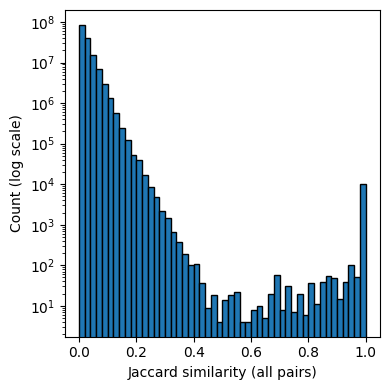

In [110]:
n = len(data)
total_pairs = math.comb(n, 2)

nonzero_pairs = len(df)
missing_zero_pairs = total_pairs - nonzero_pairs
zero_percentage = (missing_zero_pairs / total_pairs) * 100
vals = df["Jaccard_Similarity"].to_numpy()
# add the implicit zeros
vals_with_zeros = np.concatenate(
    [vals, np.zeros(missing_zero_pairs, dtype=float)]
)

# Count high similarity matches at different thresholds (existing)
thresholds = [1.0, 0.9, 0.75, 0.5, 0.3, 0.1]
print("High similarity pairs:")
for thresh in thresholds:
    count = np.sum(vals >= thresh)
    percentage = (count / total_pairs) * 100
    print(f"≥ {thresh}: {count:,} ({percentage:.1f}%)")

# NEW: Cumulative distribution from 0 to x (percentage of pairs with similarity <= x)
print("\nCumulative from 0:")
x_values = np.linspace(0, 1, 11)  # 0.0, 0.1, 0.2, ..., 1.0
for x in x_values:
    count_leq_x = np.sum(vals_with_zeros <= x)
    percentage_leq_x = (count_leq_x / total_pairs) * 100
    print(f"≤ {x:.1f}: {count_leq_x:,} ({percentage_leq_x:.1f}%)")

print(f"\nTotal pairs: {total_pairs:,}")
print(f"Zero similarity pairs: {missing_zero_pairs:,} ({zero_percentage:.1f}%)")

plt.figure(figsize=(4,4))
plt.hist(vals_with_zeros, bins=50, edgecolor="black", log=True)
plt.xlabel("Jaccard similarity (all pairs)")
plt.ylabel("Count (log scale)")
plt.tight_layout()
plt.show()


In [82]:
df = df.copy()
df["min_id"] = df[["Sentence1", "Sentence2"]].min(axis=1)
df["max_id"] = df[["Sentence1", "Sentence2"]].max(axis=1)
df = df.drop_duplicates(subset=["min_id", "max_id"])

In [83]:
df

,Sentence1,Sentence2,Jaccard_Similarity,min_id,max_id
0,1,2,0.0303,1,2
1,1,3,0.0345,1,3
2,1,6,0.0690,1,6
3,1,9,0.0556,1,9
4,1,10,0.0294,1,10
...,...,...,...,...,...
70662963,17563,17567,0.0444,17563,17567
70662964,17564,17565,0.0312,17564,17565
70662965,17564,17566,0.0857,17564,17566
70662966,17565,17567,0.0303,17565,17567


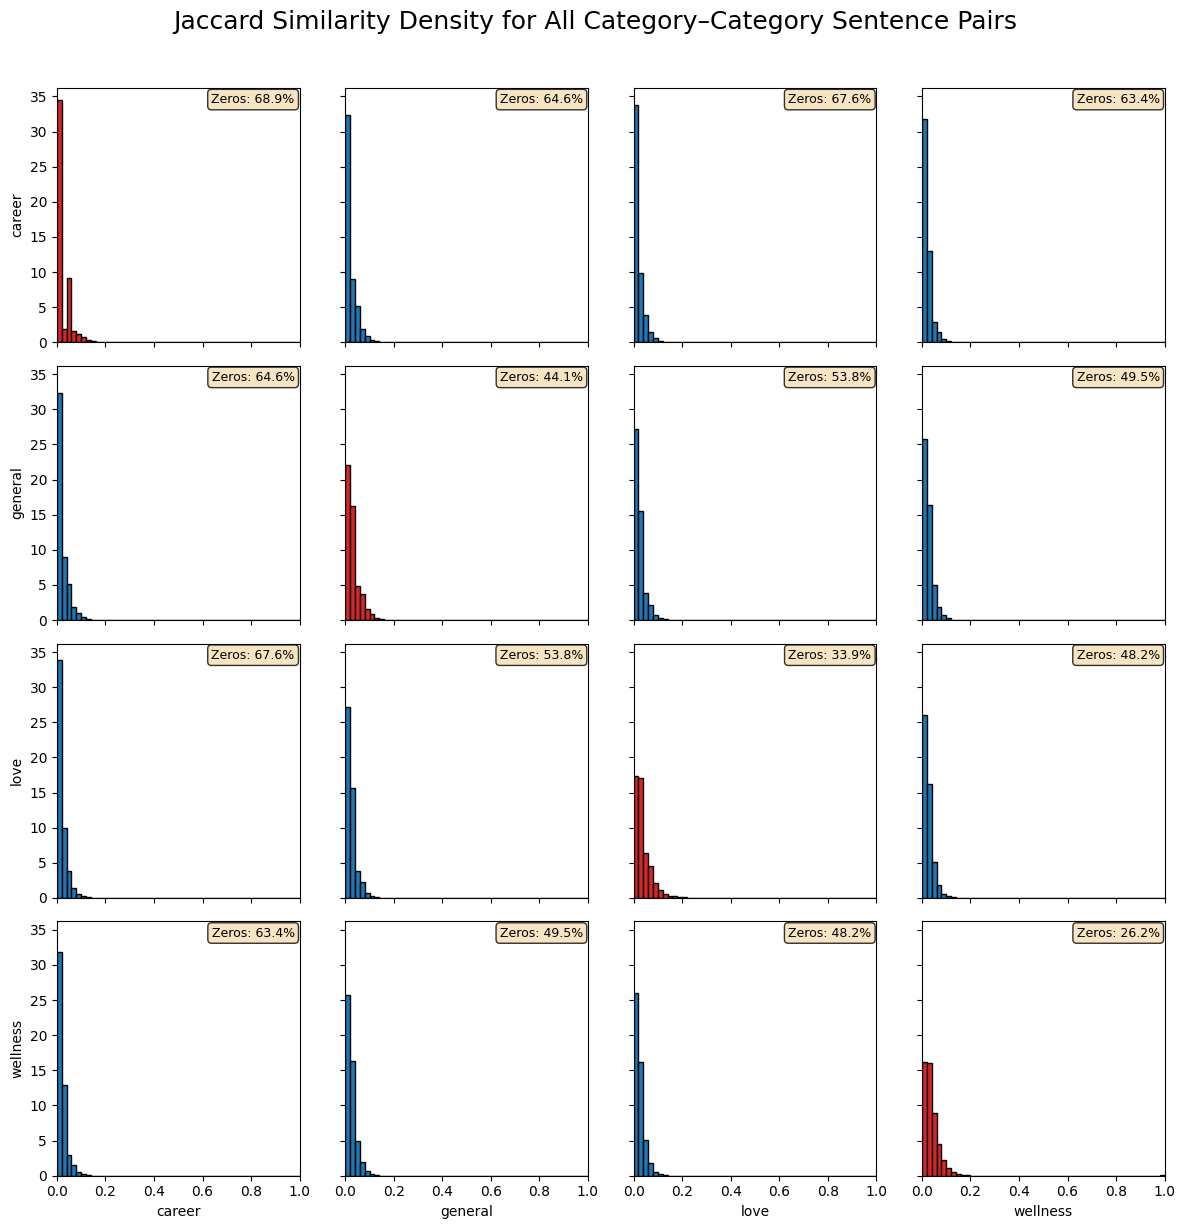

In [132]:
import math
import numpy as np
import matplotlib.pyplot as plt

# 1. Indices per category
categories = sorted(data["category"].unique())

idx_by_category = {
    cat: data.index[data["category"] == cat].tolist()
    for cat in categories
}

# 2. Grid
n = len(categories)
fig, axes = plt.subplots(n, n, figsize=(3 * n, 3 * n),
                         sharex=True, sharey=True)

bins = np.linspace(0, 1, 51)

# Storage for stats
stats = {}

for i, cat_row in enumerate(categories):
    idx_row = set(idx_by_category[cat_row])
    
    for j, cat_col in enumerate(categories):
        ax = axes[i, j]
        idx_col = set(idx_by_category[cat_col])
        
        mask = (
            (df["min_id"].isin(idx_row) & df["max_id"].isin(idx_col)) |
            (df["min_id"].isin(idx_col) & df["max_id"].isin(idx_row))
        )
        df_pair = df[mask]
        
        n_row = len(idx_row)
        n_col = len(idx_col)
        
        if cat_row == cat_col:
            total_pairs = math.comb(n_row, 2)
        else:
            total_pairs = n_row * n_col
        
        nonzero_pairs = len(df_pair)
        missing_zero_pairs = max(total_pairs - nonzero_pairs, 0)
        zero_percentage = (missing_zero_pairs / total_pairs) * 100
        
        key = f"{cat_row} vs {cat_col}"
        stats[key] = {
            "total_pairs": total_pairs,
            "zero_count": missing_zero_pairs,
            "zero_pct": zero_percentage,
            "nonzero_pairs": nonzero_pairs,
        }
        
        vals = df_pair["Jaccard_Similarity"].to_numpy()
        vals_all = np.concatenate(
            [vals, np.zeros(missing_zero_pairs, dtype=float)]
        )
        
        color = "tab:red" if i == j else "tab:blue"
        
        ax.hist(
            vals_all,
            bins=bins,
            edgecolor="black",
            color=color,
            density=True,  # y-axis = probability density
        )
        ax.set_xlim(0, 1)
        
        # show only percentage of zeros
        ax.text(
            0.98,
            0.98,
            f"Zeros: {zero_percentage:.1f}%",
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment="top",
            horizontalalignment="right",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
        )
        
        if i == n - 1:
            ax.set_xlabel(cat_col)
        if j == 0:
            ax.set_ylabel(cat_row)

for ax in axes.ravel():
    if ax.has_data():
        ax.set_xlim(0, 1)

plt.suptitle(
    "Jaccard Similarity Density for All Category–Category Sentence Pairs",
    fontsize=18,
    y=1.02,
)
plt.tight_layout()
plt.show()



In [133]:
# SIMPLE DATASET - Just zeros and percentages
zero_stats = pd.DataFrame({
    'row_category': [],
    'col_category': [],
    'zero_count': [],
    'zero_percentage': []
})

for i, cat_row in enumerate(categories):
    for j, cat_col in enumerate(categories):
        key = f"{cat_row} vs {cat_col}"
        s = stats[key]
        zero_stats = pd.concat([zero_stats, pd.DataFrame({
            'row_category': [cat_row],
            'col_category': [cat_col],
            'zero_count': [s['zero_count']],
            'zero_percentage': [s['zero_pct']]
        })], ignore_index=True)

zero_stats

# 1. Add a flag for within vs between
zero_stats["within"] = zero_stats["row_category"] == zero_stats["col_category"]

# 2. For each row_category, compute:
#    - zero% within that category (row vs same col)
#    - mean zero% vs all *other* categories
summary = (
    zero_stats
    .groupby("row_category")
    .apply(lambda df_row: pd.Series({
        "within_zero_pct": df_row.loc[df_row["within"], "zero_percentage"].iloc[0],
        "between_mean_zero_pct": df_row.loc[~df_row["within"], "zero_percentage"].mean()
    }))
    .reset_index()
)

summary


/var/folders/7n/g80l5_jd4fdc9g9m7qbj6mdr0000gn/T/ipykernel_42256/3404540816.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df_row: pd.Series({


,row_category,within_zero_pct,between_mean_zero_pct
0,career,68.943067,65.198515
1,general,44.121757,55.974793
2,love,33.915363,56.514099
3,wellness,26.238468,53.675049


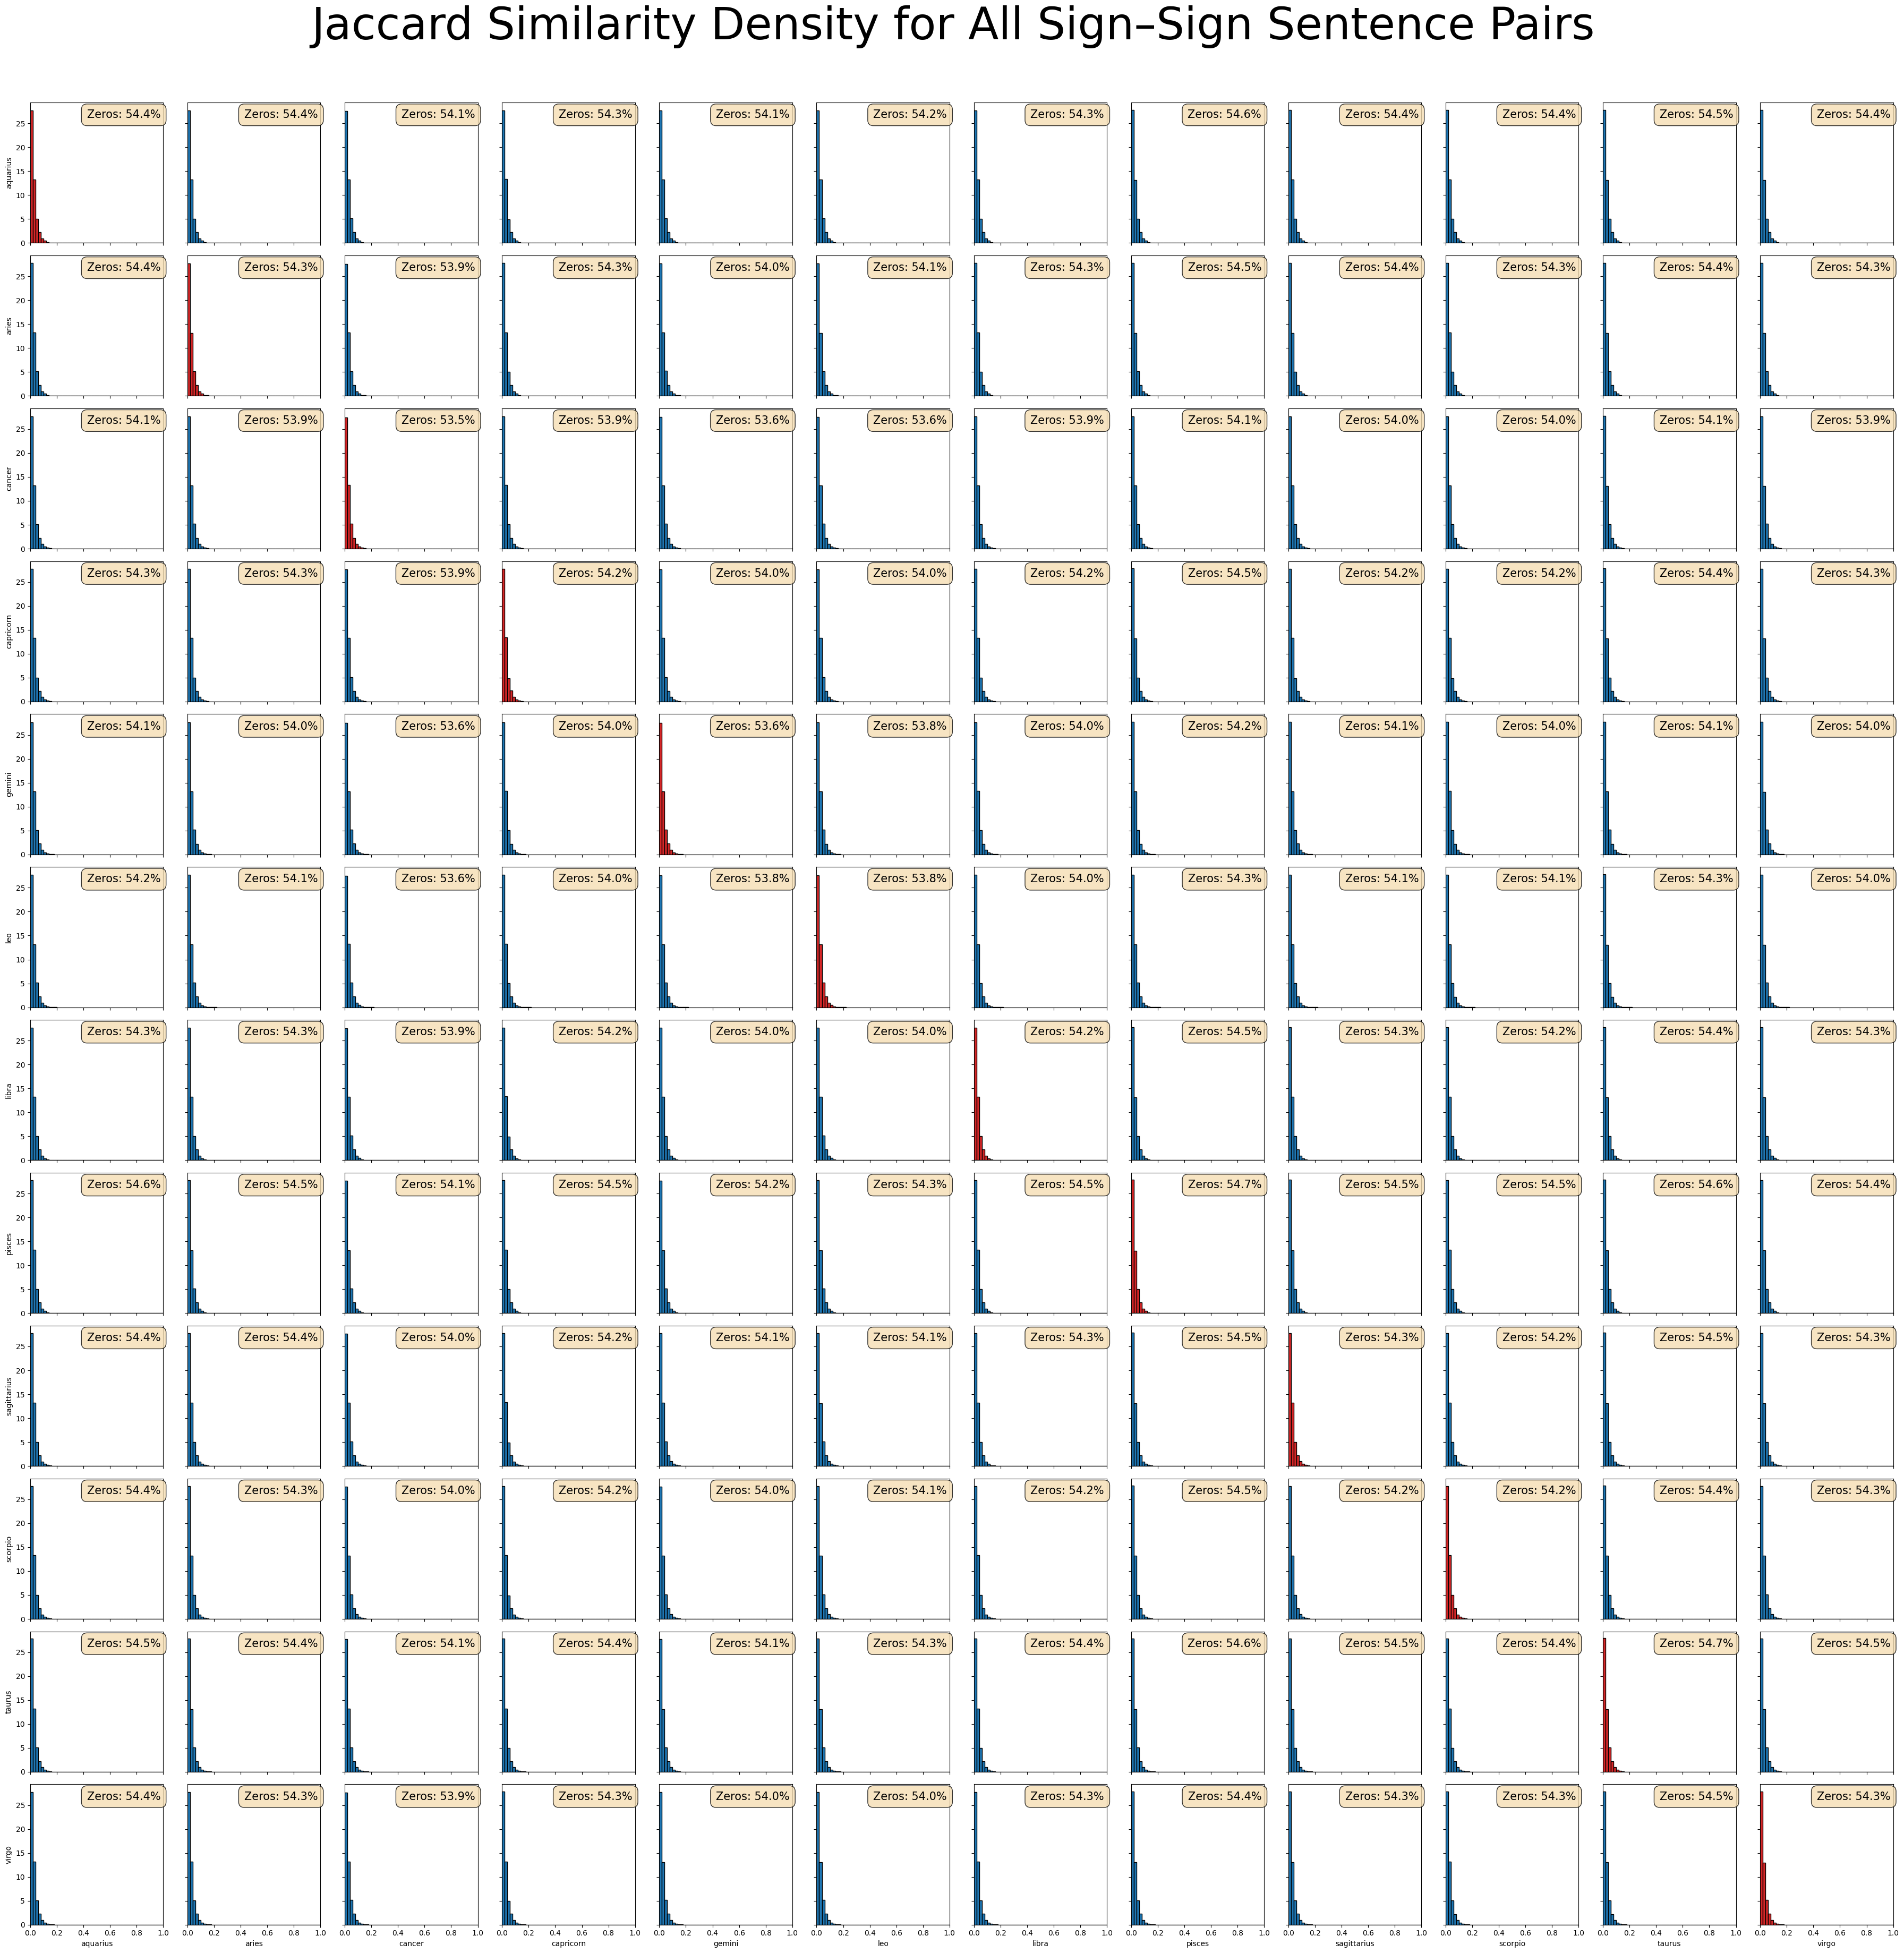

In [136]:
import math
import numpy as np
import matplotlib.pyplot as plt

# 1. Indices per sign
signs = sorted(data["sign"].unique())

idx_by_sign = {
    sig: data.index[data["sign"] == sig].tolist()
    for sig in signs
}

# 2. Grid
n = len(signs)
fig, axes = plt.subplots(n, n, figsize=(3 * n, 3 * n),
                         sharex=True, sharey=True)

bins = np.linspace(0, 1, 51)

# Storage for stats
stats = {}

for i, sign_row in enumerate(signs):
    idx_row = set(idx_by_sign[sign_row])
    
    for j, sign_col in enumerate(signs):
        ax = axes[i, j]
        idx_col = set(idx_by_sign[sign_col])
        
        mask = (
            (df["min_id"].isin(idx_row) & df["max_id"].isin(idx_col)) |
            (df["min_id"].isin(idx_col) & df["max_id"].isin(idx_row))
        )
        df_pair = df[mask]
        
        n_row = len(idx_row)
        n_col = len(idx_col)
        
        if sign_row == sign_col:
            total_pairs = math.comb(n_row, 2)
        else:
            total_pairs = n_row * n_col
        
        nonzero_pairs = len(df_pair)
        missing_zero_pairs = max(total_pairs - nonzero_pairs, 0)
        zero_percentage = (missing_zero_pairs / total_pairs) * 100
        
        key = f"{sign_row} vs {sign_col}"
        stats[key] = {
            "total_pairs": total_pairs,
            "zero_count": missing_zero_pairs,
            "zero_pct": zero_percentage,
            "nonzero_pairs": nonzero_pairs,
        }
        
        vals = df_pair["Jaccard_Similarity"].to_numpy()
        vals_all = np.concatenate(
            [vals, np.zeros(missing_zero_pairs, dtype=float)]
        )
        
        color = "tab:red" if i == j else "tab:blue"
        
        ax.hist(
            vals_all,
            bins=bins,
            edgecolor="black",
            color=color,
            density=True,  # y-axis = probability density
        )
        ax.set_xlim(0, 1)
        
        # show only percentage of zeros
        ax.text(
            0.98,
            0.95,  # Lowered slightly for more box space
            f"Zeros: {zero_percentage:.1f}%",
            transform=ax.transAxes,
            fontsize=15,  # Slightly larger font
            verticalalignment="top",
            horizontalalignment="right",
            bbox=dict(
                boxstyle="round,pad=0.5",  # Increased padding
                facecolor="wheat", 
                alpha=0.8
            ),
)
        
        if i == n - 1:
            ax.set_xlabel(sign_col)
        if j == 0:
            ax.set_ylabel(sign_row)

for ax in axes.ravel():
    if ax.has_data():
        ax.set_xlim(0, 1)

plt.suptitle(
    "Jaccard Similarity Density for All Sign–Sign Sentence Pairs",
    fontsize=60,
    y=1.02,
)
plt.tight_layout()
plt.show()


In [137]:
# UPDATED to match dataframe construction with lists for performance

rows = []
for i, cat_row in enumerate(signs):
    for j, cat_col in enumerate(signs):
        key = f"{cat_row} vs {cat_col}"
        s = stats[key]
        rows.append({
            'row_category': cat_row,
            'col_category': cat_col,
            'zero_count': s['zero_count'],
            'zero_percentage': s['zero_pct'],
            'within': cat_row == cat_col
        })
zero_stats = pd.DataFrame(rows)

# Compute summary with clear naming and safer indexing
summary = (
    zero_stats
    .groupby("row_category")
    .apply(lambda df_row: pd.Series({
        "within_zero_pct": df_row.loc[df_row["within"], "zero_percentage"].values[0] if not df_row.loc[df_row["within"]].empty else np.nan,
        "between_mean_zero_pct": df_row.loc[~df_row["within"], "zero_percentage"].mean()
    }))
    .reset_index()
)

summary


/var/folders/7n/g80l5_jd4fdc9g9m7qbj6mdr0000gn/T/ipykernel_42256/1196603421.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df_row: pd.Series({


,row_category,within_zero_pct,between_mean_zero_pct
0,aquarius,54.436763,54.331228
1,aries,54.272511,54.259136
2,cancer,53.510733,53.923209
3,capricorn,54.192112,54.217230
4,gemini,53.627175,53.978325
5,leo,53.774152,54.047060
6,libra,54.208920,54.206076
7,pisces,54.748552,54.417621
8,sagittarius,54.272978,54.255089
9,scorpio,54.227783,54.231901


In [ ]:
import math
import numpy as np
import pandas as pd

# 1. Indices per category (your exact code)
categories = sorted(data["category"].unique())
idx_by_category = {
    cat: data.index[data["category"] == cat].tolist()
    for cat in categories
}

# Choose ONE category
chosen_category = categories[0]  # or categories[2], etc.
category_indices = set(idx_by_category[chosen_category])

# 2. Get all signs within this category
category_data = data[data.index.isin(category_indices)]
signs = sorted(category_data["sign"].unique())

# 3. Indices per sign WITHIN chosen category
idx_by_sign = {
    sign: [idx for idx in data.index[data["sign"] == sign].tolist() 
           if idx in category_indices]
    for sign in signs
}

# 4. Calculate stats for ALL sign combinations within category
rows = []
for sign_row in signs:
    for sign_col in signs:
        idx_row = set(idx_by_sign[sign_row])
        idx_col = set(idx_by_sign[sign_col])
        
        # Filter df to this sign pair
        mask = (
            (df["min_id"].isin(idx_row) & df["max_id"].isin(idx_col)) |
            (df["min_id"].isin(idx_col) & df["max_id"].isin(idx_row))
        )
        df_pair = df[mask]
        
        n_row = len(idx_row)
        n_col = len(idx_col)
        
        if sign_row == sign_col:
            total_pairs = math.comb(n_row, 2)
        else:
            total_pairs = n_row * n_col
            
        nonzero_pairs = len(df_pair)
        zero_count = max(total_pairs - nonzero_pairs, 0)
        zero_percentage = (zero_count / total_pairs) * 100
        
        rows.append({
            'category': chosen_category,
            'sign_row': sign_row,
            'sign_col': sign_col,
            'n_items_row': n_row,
            'n_items_col': n_col,
            'total_pairs': total_pairs,
            'zero_count': zero_count,
            'zero_percentage': zero_percentage,
            'nonzero_pairs': nonzero_pairs,
            'within_sign': sign_row == sign_col
        })

sign_stats = pd.DataFrame(rows)

,category,sign_row,sign_col,n_items_row,n_items_col,total_pairs,zero_count,zero_percentage,nonzero_pairs,within_sign
0,career,aquarius,aquarius,366,366,66795,46091,69.003668,20704,True
1,career,aquarius,aries,366,366,133956,92916,69.363074,41040,False
2,career,aquarius,cancer,366,366,133956,91706,68.459793,42250,False
3,career,aquarius,capricorn,366,366,133956,92181,68.814387,41775,False
4,career,aquarius,gemini,366,366,133956,92283,68.890531,41673,False
...,...,...,...,...,...,...,...,...,...,...
139,career,virgo,pisces,366,366,133956,93739,69.977455,40217,False
140,career,virgo,sagittarius,366,366,133956,91934,68.629998,42022,False
141,career,virgo,scorpio,366,366,133956,91349,68.193287,42607,False
142,career,virgo,taurus,366,366,133956,92797,69.274239,41159,False


In [170]:
within = sign_stats[sign_stats["within_sign"]]
within_simple = within[["category","sign_row", "zero_percentage"]]


# drop those rows from sign_stats
sign_stats_no_within = sign_stats[~sign_stats["within_sign"]]

mean_zero_by_sign = (
    sign_stats
    .groupby("sign_row")["zero_percentage"]
    .mean()
    .reset_index(name="mean_zero_percentage")
)

final_df = (
    within_simple
    .merge(
        mean_zero_by_sign,        # has sign_row, mean_zero_percentage
        on="sign_row",
        how="left"
    )
)
final_df

,category,sign_row,zero_percentage,mean_zero_percentage
0,career,aquarius,69.003668,69.012310
1,career,aries,70.169923,69.515850
2,career,cancer,67.208623,68.256180
3,career,capricorn,68.674302,68.779571
4,career,gemini,68.690770,68.899515
5,career,leo,68.579984,68.952057
6,career,libra,68.328468,68.600889
7,career,pisces,70.610076,69.799376
8,career,sagittarius,68.470694,68.859340
9,career,scorpio,67.789505,68.524560
